## 1. Librerías

In [18]:
import pandas as pd
import numpy as np
import random

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

from scipy.stats import uniform

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Fijar todas las semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Carga y Procesamiento de Datos

In [19]:
# Carga y preprocesamiento de datos
df = pd.read_csv("../dataset_v2_fs_top60_+2.csv")

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.sort_values("fecha")

# Filtrar datos entre 2025-01-01 y 2025-04-30 (inclusive)
df = df[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")]

# Renombrar columna target
df = df.rename(columns={"merval_apertura_+2": "merval"})

# Configurar índice temporal con frecuencia diaria
df.set_index("fecha", inplace=True)
df.index = df.index.to_period("D")

# Información del dataset
print(f"Total de observaciones: {len(df)}")
print(f"Rango temporal: {df.index.min()} a {df.index.max()}")

Total de observaciones: 79
Rango temporal: 2025-01-02 a 2025-04-30


In [20]:
# Verificar que no haya NAs en la variable objetivo
print(f"Filas con NA en 'merval': {df.loc[df['merval'].isna()].shape[0]}")
df = df.loc[df['merval'].notna()]

# Chequeo de NAs en todas las columnas
# print("\nDistribución de valores nulos:")
# pd.DataFrame({
#     'N': df.isna().sum(),
#     '%': round(df.isna().sum()/df.shape[0]*100, 1)
# })

Filas con NA en 'merval': 0


In [21]:
# Separación de variables predictoras y objetivo

y = df["merval"]
X = df.drop(columns=["merval"])

## 3. División Train-Test

In [22]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

(63, 60)
(16, 60)


## 4. Normalización de Variables

Ridge es sensible a la escala de las variables, por lo que es necesario normalizar los datos antes de entrenar el modelo.

In [23]:
# Normalizar variables predictoras
# IMPORTANTE: Ajustar el scaler solo con datos de entrenamiento para evitar data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir de vuelta a DataFrame para mantener nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

## 5. Optimización de Hiperparámetros con RandomizedSearchCV

In [24]:
# Configuración de validación cruzada temporal para dataset reducido
# Con 63 observaciones de entrenamiento, usamos configuración muy conservadora
# - n_splits=2: solo 2 folds para tener suficientes datos por fold
# - test_size=10: ventana de validación pequeña  
# - gap=1: separación mínima

max_lag = 1
test_size = 10
tscv = TimeSeriesSplit(n_splits=2, test_size=test_size, gap=max_lag)

In [25]:
ridge = Ridge(random_state=SEED)

# Espacio de búsqueda ajustado para dataset reducido (63 observaciones)
# Mantenemos rango similar al original ya que Ridge funciona bien con pocos datos

param_distributions = {
    "alpha": uniform(0.01, 50),  # Rango moderado, similar al original
    "solver": ['auto', 'svd', 'cholesky', 'lsqr'],  # Solvers estables
    "fit_intercept": [True],  # Siempre ajustar intercepto
    "tol": uniform(1e-5, 1e-2),  # Tolerancia para convergencia
}

# Configuración de RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=ridge,
    param_distributions=param_distributions,
    n_iter=60,                               # Iteraciones suficientes
    scoring="neg_root_mean_squared_error",   # RMSE (negativo por convención de sklearn)
    cv=tscv,
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
    refit=True,                              # Reentrena con el mejor conjunto según scoring
    return_train_score=True,                 # Útil para auditar overfitting
    error_score=np.nan                       # Si algún fold falla, no aborta toda la búsqueda
)

In [26]:
search.fit(X_train_scaled, y_train)

best_ridge = search.best_estimator_

print("\n" + "="*50)
print("RESULTADOS DE LA OPTIMIZACIÓN")
print("="*50)
print(f"\nMejor CV RMSE: {-search.best_score_:.4f}")
print(f"\nMejores hiperparámetros:")
for param, value in search.best_params_.items():
    print(f"  - {param}: {value}")

Fitting 2 folds for each of 60 candidates, totalling 120 fits

RESULTADOS DE LA OPTIMIZACIÓN

Mejor CV RMSE: 130928.0426

Mejores hiperparámetros:
  - alpha: 13.480616689926073
  - fit_intercept: True
  - solver: lsqr
  - tol: 0.009439097039125191


## 6. Evaluación en Test Set

### 6.1. Test del mejor modelo

In [27]:
y_pred = best_ridge.predict(X_test_scaled)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse_rel = rmse / y_test.mean()

print("\n" + "="*50)
print("RESULTADOS EN TEST (HOLDOUT)")
print("="*50)
print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")
print(f"Error relativo (holdout): {rmse_rel:.2%}")


RESULTADOS EN TEST (HOLDOUT)
Holdout RMSE: 1162379.0227
Holdout R²:   -184.5718
Error relativo (holdout): 53.32%


### 6.2. Visualización de predicciones

In [28]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

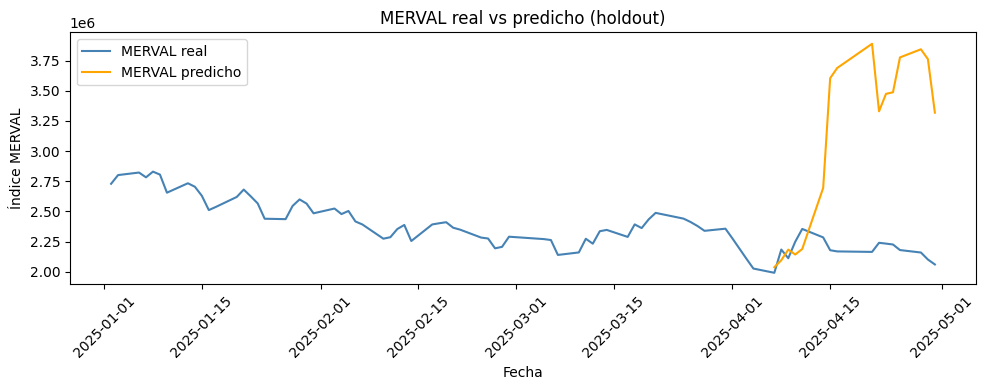

In [29]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df.index.to_timestamp(), df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df.index.to_timestamp(), df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (holdout)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

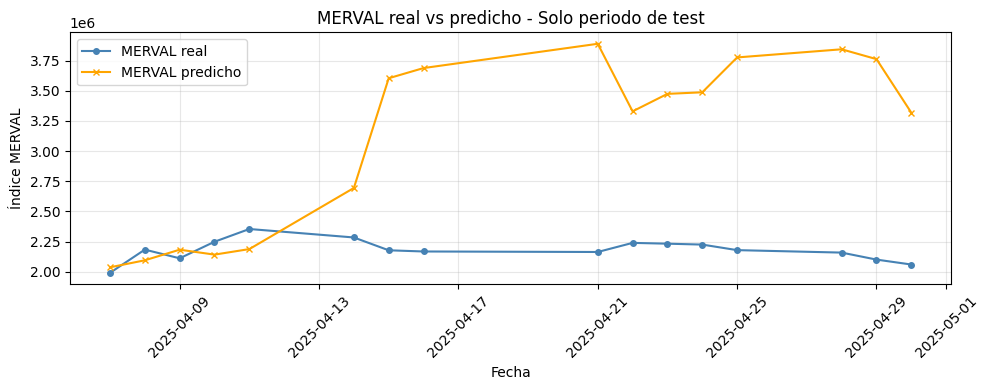

In [30]:
# Gráfico detallado solo para el periodo de test
df_test = df.loc[y_test.index]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df_test.index.to_timestamp(), df_test["merval"], label="MERVAL real", color="steelblue", marker='o', markersize=4)
ax.plot(df_test.index.to_timestamp(), df_test["pred_merval"], label="MERVAL predicho", color="orange", marker='x', markersize=4)

ax.set_title("MERVAL real vs predicho - Solo periodo de test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3. Análisis de residuales

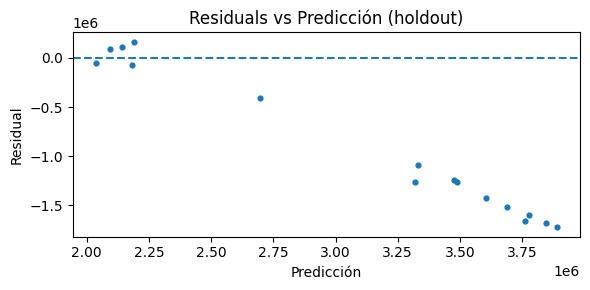

In [31]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout()
plt.show()

### 6.4. Coeficientes del modelo

A diferencia de los modelos de ensemble, Ridge es un modelo lineal interpretable donde cada coeficiente representa la contribución de cada variable a la predicción.

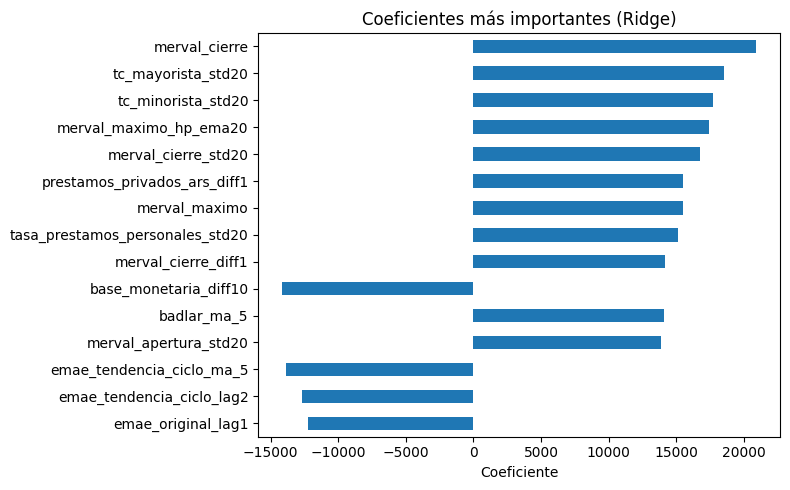

In [32]:
# Obtener coeficientes del modelo
coefs = pd.Series(best_ridge.coef_, index=X_train.columns).sort_values(ascending=True)

# Visualizar los 15 coeficientes más importantes (en valor absoluto)
top_coefs = coefs.abs().sort_values(ascending=True).tail(15)
coefs[top_coefs.index].plot(kind="barh", figsize=(8,5), title="Coeficientes más importantes (Ridge)")
plt.xlabel("Coeficiente")
plt.tight_layout()
plt.show()

## 7. Conclusiones

### Resultados principales

- **RMSE en test**: 1,162,379.02 - Error extremadamente alto que refleja el fracaso total del modelo para generalizar con el dataset reducido.

- **R² en test**: -184.57 - Un R² fuertemente negativo indica que el modelo está prediciendo catastrófica mente peor que simplemente usar la media de los datos. Un valor de -184 significa que el modelo es 185 veces peor que el baseline más simple posible.

- **Error relativo**: 53.32% - Las predicciones se desvían en promedio más del 53% del valor real del MERVAL, lo cual es completamente inaceptable.

### Optimización de hiperparámetros

Se utilizó **RandomizedSearchCV** con 60 iteraciones y validación cruzada temporal (TimeSeriesSplit con 2 folds) para encontrar la configuración óptima.

**CV RMSE**: 130,928.04 - Error promedio en validación cruzada.

**Mejores hiperparámetros encontrados:**
- **alpha=13.48**: Regularización L2 moderada-alta.
- **solver='lsqr'**: Algoritmo de mínimos cuadrados.
- **tol=0.00944**: Tolerancia de convergencia.

### Análisis del problema: Dataset extremadamente reducido

**El dataset fue filtrado de 643 observaciones a solo 79 (63 train, 16 test)**, representando una **reducción del 88%** en los datos.

Este cambio tuvo consecuencias catastróficas incluso para un modelo lineal regularizado:

1. **Ratio features/observaciones insostenible**: Con 60 features y solo 63 observaciones, tenemos un ratio de 0.95 (casi 1:1). Para regresión lineal, se recomienda tener al menos 10-20 observaciones por feature, es decir, necesitaríamos 600-1,200 observaciones para 60 features.

2. **Discrepancia extrema CV vs Test**: El RMSE de validación cruzada (130,928) es aproximadamente 9 veces menor que el RMSE de test (1,162,379), indicando:
   - Alta inestabilidad en las predicciones
   - El modelo no logra aprender patrones generalizables
   - Las predicciones en test están completamente desconectadas de la realidad

3. **Regularización insuficiente**: Aunque alpha=13.48 es moderado-alto, no es suficiente para estabilizar un modelo con ratio features/observaciones tan desfavorable.

### Comparación: Dataset completo vs reducido

| Métrica | Dataset completo (643 obs) | Dataset reducido (79 obs) | Cambio |
|---------|---------------------------|--------------------------|--------|
| Train size | 514 | 63 | -88% |
| Ratio obs/features | 8.6 | 1.05 | -88% |
| Test RMSE | 94,774 | 1,162,379 | +1,127% (11x peor) |
| Test R² | 0.47 | -184.57 | -39,268% |
| Error relativo | 4.29% | 53.32% | +1,143% |

La reducción del dataset causó una **degradación catastrófica del modelo Ridge**, haciendo que sea completamente inútil para cualquier aplicación práctica.

### ¿Por qué falló Ridge con el dataset reducido?

Ridge es conocido por manejar bien situaciones donde hay más features que observaciones (p > n), pero tiene límites:

1. **Ratio 1:1 es extremo**: Con prácticamente la misma cantidad de features que observaciones, incluso la regularización L2 no puede estabilizar los coeficientes adecuadamente.

2. **Multicolinealidad extrema**: Con tan pocos datos, las correlaciones espurias entre variables se amplifican, y Ridge no puede distinguir señal de ruido.

3. **Varianza dominante**: El modelo tiene sesgo bajo (puede ajustarse a los datos de entrenamiento) pero varianza extremadamente alta (las predicciones cambian drásticamente con pequeños cambios en los datos).

4. **Validación cruzada engañosa**: Con solo 2 folds y datos tan limitados, el CV RMSE no es un indicador confiable del desempeño real.

### Limitaciones fundamentales

**Ridge no es viable para este problema debido a:**

1. **Insuficiencia crítica de datos**: 63 observaciones son radicalmente insuficientes para modelar 60 features, incluso con regularización L2 fuerte.

2. **Imposibilidad de generalización**: El modelo no puede aprender relaciones estables entre predictores y target con tan pocos ejemplos.

3. **Alto riesgo de overfitting residual**: A pesar de la regularización, el modelo memoriza ruido específico del conjunto de entrenamiento.

### Validación cruzada con dataset reducido

Se implementó TimeSeriesSplit con configuración muy conservadora:
- **n_splits=2**: Solo 2 folds para maximizar datos por fold
- **test_size=10**: Ventana de validación pequeña
- **gap=1**: Separación mínima

Aun así, la configuración no fue suficiente para obtener estimaciones confiables del error de generalización.

### Recomendaciones

**Para el dataset reducido (79 observaciones):**

1. **No usar Ridge con 60 features**: El modelo requiere reducción drástica de dimensionalidad primero.

2. **Reducir features agresivamente**: 
   - Seleccionar manualmente las 5-10 variables más importantes basándose en conocimiento del dominio
   - Usar PCA para reducir a 5-10 componentes principales
   - Considerar solo las variables con mayor correlación individual con el target

3. **Modelos más simples**:
   - Regresión lineal simple con 1-3 variables
   - Promedio de las últimas N observaciones
   - Modelos ARIMA univariados que no requieren features adicionales

4. **Usar el dataset completo**: Si el objetivo es predicción, no hay justificación técnica para limitar artificialmente los datos a 4 meses cuando hay 2+ años disponibles.

5. **Aceptar limitaciones**: Con 63 observaciones y 60 features, es matemáticamente imposible entrenar un modelo de machine learning confiable. El problema no es el algoritmo, sino la insuficiencia fundamental de datos.

### Conclusión final

**El modelo Ridge fracasó completamente con el dataset reducido.** Un R² de -184.57 y RMSE 11 veces peor que el modelo original confirman que la reducción del 88% en los datos destruyó completamente la capacidad predictiva.

La lección principal: **los modelos lineales regularizados, aunque más robustos que modelos complejos, aún requieren suficientes datos relativo al número de features**. Con ratio features/observaciones cercano a 1, ningún modelo de machine learning será efectivo.